# 🗂️ 08: LLM Wiki Compilation — Karpathy's LLMWiki 패턴

---

| 항목 | 내용 |
|------|------|
| **목표** | LLM을 Q&A 봇이 아닌 **지식 편집 엔진**으로 활용하는 패턴을 이해한다 |
| **예상 실행 시간** | ⏱️ 빠른 시연 8분 / 전체 20분 |
| **API 키** | ✅ 권장 (없으면 rule-based fallback으로 흐름 시연) |
| **이전 노트북과의 연결** | 04~06번에서 RAG로 질문에 답하는 방법을 봤다. 이번엔 한 발 더 나아가 **재사용 가능한 지식 자산**을 만드는 패턴을 본다. |

---

## 🎯 Andrej Karpathy의 LLMWiki 아이디어

> **"LLM을 Q&A 봇으로만 쓰는 것은 반쪽짜리 활용이다.  
> LLM은 산재한 지식을 구조화된 위키 자산으로 합성하는 편집 엔진이 될 수 있다."**

Wikipedia를 생각해보자. 편집자들은 논문, 뉴스, 블로그에 흩어진 정보를 **하나의 구조화된 문서**로 합성한다.  
LLM도 같은 역할을 할 수 있다. 이것이 LLMWiki 패턴이다.

---

## RAG vs LLMWiki — 핵심 차이

```
[RAG 패턴]
질문 → 벡터 검색 → 관련 청크 3개 → LLM → 1회성 답변 (사라짐)

[LLMWiki 패턴]
소스 6개 → LLM 편집 → 구조화된 위키 초안 → 재사용 가능한 지식 자산 (남음)
```

| 항목 | RAG | LLMWiki |
|------|-----|---------|
| **목적** | 지금 질문에 답하기 | 다음에도 쓸 지식 자산 만들기 |
| **출력** | 1회성 답변 | 구조화된 위키 문서 |
| **지속성** | 없음 | 있음 (점진적 업데이트 가능) |
| **충돌 처리** | 즉흥적 | 명시적 해결 + 구버전 주의 섹션 |
| **출처** | 응답 안에 묻힘 | 섹션별 명시적 인용 |

---

## 이 노트북의 흐름

```
1️⃣ 소스 로드     — 논문, 공식문서, 블로그, FAQ, 벤치마크, 아카이브 6종
2️⃣ 소스 분석     — 타입별·날짜별 다양성 확인, 구버전 식별
3️⃣ Wiki 컴파일   — LLM이 편집자 역할: 충돌 해결 + 섹션별 인용
4️⃣ 점진적 업데이트 — 새 논문 등장 → 영향받는 섹션만 갱신
5️⃣ RAG vs Wiki   — 같은 질문에 두 방식 비교
```

In [11]:
!pip install -q openai sentence-transformers
print("✅ 완료")


✅ 완료


In [1]:
import os
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

try:
    from dotenv import load_dotenv
    from pathlib import Path
    for _p in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
        if (_p / '.env').exists():
            load_dotenv(_p / '.env')
            break
except ImportError:
    pass

OPENAI_API_KEY = os.environ.get('OPENAI_API_KEY', '')

def setup(api_key=''):
    key = api_key or os.environ.get('OPENAI_API_KEY', '')
    if key and key not in ('', 'sk-...'):
        try:
            from openai import OpenAI
            client = OpenAI(api_key=key)
            print('✅ API 모드')
            return 'api', client
        except Exception:
            pass
    print('💡 로컬 모드 - rule-based wiki compilation 사용')
    return 'local', None

MODE, client = setup(OPENAI_API_KEY)

_st_model = None

def embed(texts):
    global _st_model
    if MODE == 'api' and client:
        try:
            vecs = []
            for i in range(0, len(texts), 50):
                resp = client.embeddings.create(input=texts[i:i+50], model='text-embedding-3-small')
                vecs.extend([r.embedding for r in resp.data])
            return np.array(vecs, dtype=np.float32)
        except Exception:
            pass
    if _st_model is None:
        print('📥 임베딩 모델 로딩...')
        from sentence_transformers import SentenceTransformer
        _st_model = SentenceTransformer('all-MiniLM-L6-v2')
        print('✅')
    return _st_model.encode(texts, convert_to_numpy=True, show_progress_bar=False).astype(np.float32)

def cos_sim(q, docs):
    q = np.array(q, dtype=np.float32).flatten()
    docs = np.array(docs, dtype=np.float32)
    qn = np.linalg.norm(q)
    if qn < 1e-9:
        return np.zeros(len(docs))
    dn = np.linalg.norm(docs, axis=1)
    dn = np.where(dn < 1e-9, 1e-9, dn)
    return (docs @ q) / (dn * qn)

def estimate_tokens(text):
    return max(1, len(text) // 4)

def call_llm(prompt, system='당신은 내부 위키 편집자입니다.', temperature=0.2, fallback=None):
    if MODE == 'api' and client:
        try:
            resp = client.chat.completions.create(
                model='gpt-4o-mini',
                messages=[
                    {'role': 'system', 'content': system},
                    {'role': 'user', 'content': prompt},
                ],
                temperature=temperature,
                max_tokens=1100,
            )
            return resp.choices[0].message.content.strip()
        except Exception as e:
            print(f'⚠️ {e}')
    if callable(fallback):
        return fallback()
    return fallback or '[로컬 모드]'

print(f'모드: {MODE}')


✅ API 모드
모드: api


## 1️⃣ 소스 로드 — "프롬프트 엔지니어링"에 관한 6가지 소스

Wikipedia 편집자가 "프롬프트 엔지니어링" 문서를 쓴다면 어디서 정보를 모을까?

- 📄 **학술 논문**: 이론적 근거와 수치 (CoT 논문)
- 📘 **공식 문서**: 현재 best practice (OpenAI 가이드)
- 📝 **엔지니어링 블로그**: 실전 경험 (Anthropic 블로그)
- 💬 **커뮤니티 FAQ**: 흔한 오해와 질문
- 📊 **벤치마크 보고서**: 기법별 성능 수치
- 📦 **아카이브**: GPT-3 시대 가이드 (일부 outdated)

이 6가지가 각각 다른 관점을 갖고, 일부는 서로 **충돌하거나** 시대가 달라 **구버전 주의**가 필요하다.

In [2]:
import sys
from pathlib import Path

def _ensure_project_root_on_path():
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    for candidate in candidates:
        if (candidate / 'helpers' / 'sample_data.py').exists():
            candidate_str = str(candidate)
            if candidate_str not in sys.path:
                sys.path.insert(0, candidate_str)
            return
    raise ModuleNotFoundError('프로젝트 루트를 찾지 못했습니다.')

_ensure_project_root_on_path()

from helpers.sample_data import WIKI_SOURCE_DOCS_08, WIKI_NEW_SOURCE_08, MOCK_COMPILED_WIKI_08
import pandas as pd

DOCS = WIKI_SOURCE_DOCS_08

df = pd.DataFrame(DOCS)[['doc_id', 'title', 'source_type', 'date', 'status']]
display(df)
print(f'\n소스 문서 수: {len(DOCS)}')
print(f'current: {sum(1 for d in DOCS if d["status"] == "current")}개  |  archived: {sum(1 for d in DOCS if d["status"] == "archived")}개')

,doc_id,title,source_type,date,status
0,PAPER-COT-001,Chain-of-Thought Prompting 논문 요약,학술논문,2023-01-15,current
1,DOCS-OPENAI-PROMPT-002,OpenAI 프롬프트 엔지니어링 공식 가이드 (2024),공식문서,2024-06-10,current
2,BLOG-ANTHROPIC-PROMPT-003,Anthropic 실전 프롬프트 엔지니어링 블로그,엔지니어링블로그,2024-09-01,current
3,FAQ-COMMUNITY-PROMPT-004,프롬프트 엔지니어링 커뮤니티 FAQ,커뮤니티FAQ,2024-10-15,current
4,BENCH-PROMPT-005,프롬프트 기법별 벤치마크 비교 (2024 Q3),벤치마크,2024-08-20,current
5,ARCHIVE-PROMPT-GPT3-006,GPT-3 시대 프롬프트 작성법 (2022 구가이드),아카이브,2022-06-01,archived



소스 문서 수: 6
current: 5개  |  archived: 1개


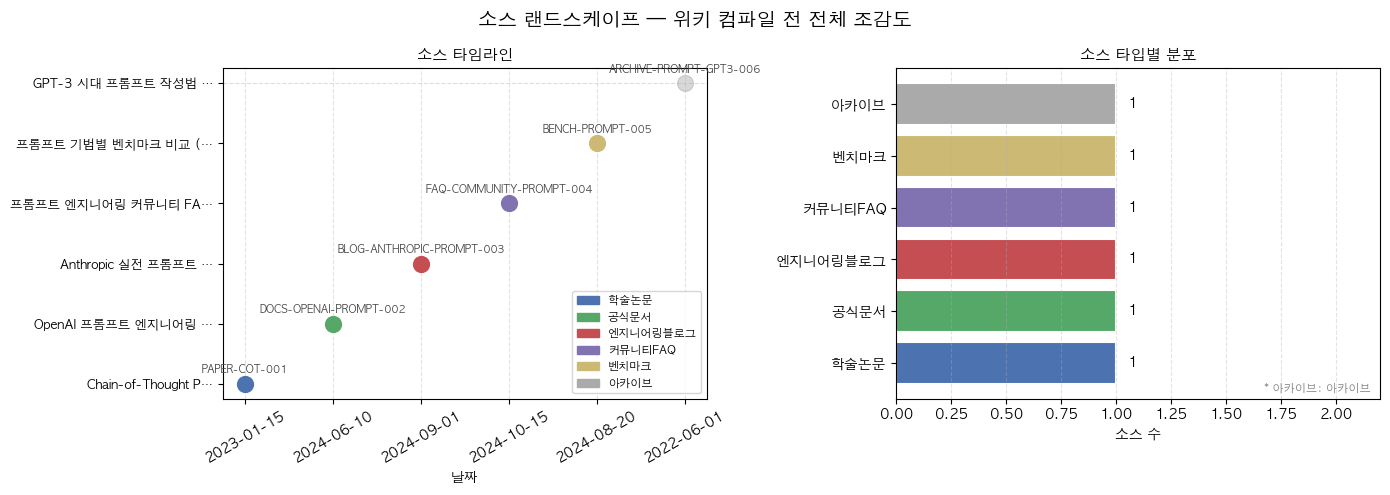


💡 다양한 소스 타입 → LLM 편집자가 통합해야 할 관점의 수


In [4]:

# ── 시각화 1: 소스 랜드스케이프 ─────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm
import platform
from collections import Counter

def _get_korean_font():
    system = platform.system()
    candidates = {
        'Darwin':  ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic'],
        'Windows': ['Malgun Gothic', 'NanumGothic'],
        'Linux':   ['NanumGothic', 'NanumBarunGothic', 'UnDotum'],
    }.get(system, ['NanumGothic', 'DejaVu Sans'])
    available = {f.name for f in fm.fontManager.ttflist}
    for font in candidates:
        if font in available:
            return font
    if system == 'Linux':
        try:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', '-q', 'fonts-nanum'],
                           capture_output=True)
            fm._rebuild()
            if 'NanumGothic' in {f.name for f in fm.fontManager.ttflist}:
                return 'NanumGothic'
        except Exception:
            pass
    return 'DejaVu Sans'

_KFONT = _get_korean_font()
plt.rcParams['font.family'] = _KFONT
plt.rcParams['axes.unicode_minus'] = False

_TYPE_COLORS = {
    '학술논문':        '#4C72B0',
    '공식문서':        '#55A868',
    '엔지니어링블로그': '#C44E52',
    '커뮤니티FAQ':     '#8172B2',
    '벤치마크':        '#CCB974',
    '아카이브':        '#aaaaaa',
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('소스 랜드스케이프 — 위키 컴파일 전 전체 조감도', fontsize=14, fontweight='bold')

# 왼쪽: 타임라인
for i, doc in enumerate(DOCS):
    color = _TYPE_COLORS.get(doc['source_type'], '#999')
    alpha = 0.45 if doc['status'] == 'archived' else 1.0
    ax1.scatter(doc['date'], i, color=color, s=130, alpha=alpha, zorder=5)
    ax1.text(doc['date'], i + 0.18, doc['doc_id'], fontsize=7.5, ha='center', color='#444')
    if doc['status'] == 'archived':
        ax1.axhline(i, color='#ddd', linewidth=0.8, linestyle='--', zorder=1)

ax1.set_yticks(range(len(DOCS)))
ax1.set_yticklabels(
    [d['title'][:18] + '…' if len(d['title']) > 18 else d['title'] for d in DOCS],
    fontsize=9,
)
ax1.set_xlabel('날짜', fontsize=10)
ax1.set_title('소스 타임라인', fontsize=11)
ax1.tick_params(axis='x', rotation=30)
ax1.grid(axis='x', linestyle='--', alpha=0.35)
patches = [mpatches.Patch(color=c, label=t) for t, c in _TYPE_COLORS.items()]
ax1.legend(handles=patches, fontsize=8, loc='lower right')

# 오른쪽: 타입별 분포
type_counts = Counter(d['source_type'] for d in DOCS)
labels = list(type_counts.keys())
counts = list(type_counts.values())
colors = [_TYPE_COLORS.get(l, '#999') for l in labels]
bars = ax2.barh(labels, counts, color=colors, edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, counts):
    ax2.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
             str(count), va='center', fontsize=10)
ax2.set_xlabel('소스 수', fontsize=10)
ax2.set_title('소스 타입별 분포', fontsize=11)
ax2.set_xlim(0, max(counts) + 1.2)
ax2.grid(axis='x', linestyle='--', alpha=0.35)
archived_types = list({d['source_type'] for d in DOCS if d['status'] == 'archived'})
if archived_types:
    ax2.text(0.98, 0.02, f'* 아카이브: {", ".join(archived_types)}',
             transform=ax2.transAxes, ha='right', fontsize=8, color='gray', style='italic')

plt.tight_layout()
plt.show()
print('\n💡 다양한 소스 타입 → LLM 편집자가 통합해야 할 관점의 수')


## 2️⃣ 소스 분석 — 다양성이 위키의 품질을 결정한다

Wikipedia의 강점은 **단일 관점이 아닌 다양한 출처의 종합**이다.  
소스 타입이 다를수록 각기 다른 각도의 사실을 커버한다.

| 소스 타입 | 강점 | 약점 |
|-----------|------|------|
| 학술논문 | 이론적 근거, 재현 가능한 수치 | 시간이 지나면 outdated |
| 공식문서 | 현재 권장 방법 | 이론적 설명 부족 |
| 엔지니어링블로그 | 실전 경험, edge case | 주관적, 검증 어려움 |
| 커뮤니티FAQ | 흔한 오해 커버 | 비공식 |
| 벤치마크 | 수치 비교 | 특정 환경에 한정 |
| 아카이브 | 역사적 맥락, 변경 이유 | **직접 채택 금지** |

💡 **편집자(LLM)의 역할**: 이 다양성을 하나의 일관된 문서로 합성하되,  
아카이브는 "구버전 주의" 섹션에서만 언급한다.

In [5]:
def analyze_sources(docs):
    """소스 다양성과 충돌 가능성을 분석한다."""
    rows = []
    for doc in docs:
        rows.append({
            '문서 ID': doc['doc_id'],
            '타입': doc['source_type'],
            '날짜': doc['date'],
            '상태': doc['status'],
            '하이라이트 수': len(doc.get('highlights', [])),
        })
    df = pd.DataFrame(rows)

    print('=== 소스 타입별 분포 ===')
    display(df.groupby('타입')['상태'].value_counts().reset_index())

    print('\n=== 주의: archived 문서 (직접 채택 금지) ===')
    archived = df[df['상태'] == 'archived']
    if not archived.empty:
        display(archived[['문서 ID', '타입', '날짜']])
    else:
        print('없음')

    print('\n=== 소스 시간 범위 ===')
    dates = sorted([d['date'] for d in docs])
    print(f'  가장 오래된 소스: {dates[0]}')
    print(f'  가장 최신 소스:   {dates[-1]}')
    gap_years = (int(dates[-1][:4]) - int(dates[0][:4]))
    print(f'  시간 범위: 약 {gap_years}년 → 구버전 정보 충돌 가능성 있음')

    return df

source_df = analyze_sources(DOCS)

=== 소스 타입별 분포 ===


,타입,상태,count
0,공식문서,current,1
1,벤치마크,current,1
2,아카이브,archived,1
3,엔지니어링블로그,current,1
4,커뮤니티FAQ,current,1
5,학술논문,current,1



=== 주의: archived 문서 (직접 채택 금지) ===


,문서 ID,타입,날짜
5,ARCHIVE-PROMPT-GPT3-006,아카이브,2022-06-01



=== 소스 시간 범위 ===
  가장 오래된 소스: 2022-06-01
  가장 최신 소스:   2024-10-15
  시간 범위: 약 2년 → 구버전 정보 충돌 가능성 있음


## 3️⃣ Wiki Compilation — LLM이 편집자 역할

이제 LLM에게 Wikipedia 편집자 역할을 맡긴다.

**편집자의 3가지 책임:**
1. **종합 (Synthesis)**: 6개 소스의 핵심을 하나의 일관된 문서로 합성
2. **충돌 해결 (Conflict resolution)**: 소스 간 상충되는 내용은 current 기준으로 결론
3. **인용 (Attribution)**: 모든 주장에 근거 문서 ID를 달아 검증 가능하게

**프롬프트 설계의 핵심**: 섹션 구조를 명시적으로 지시해야 일관성이 생긴다.  
위키를 사용하는 독자는 "개요", "주요 기법", "흔한 실수" 같은 **예측 가능한 구조**를 기대한다.

In [6]:

# ── 시각화 2: 컴파일 파이프라인 다이어그램 ───────────────────────────
from IPython.display import display, HTML

_PIPELINE_HTML = """
<style>
.pw { font-family: 'Segoe UI', sans-serif; padding: 22px 28px; background: #f8f9fa;
      border-radius: 14px; max-width: 860px; margin: 0 auto; }
.pw-title { font-size: 16px; font-weight: bold; text-align: center; margin-bottom: 18px;
            color: #1a1a2e; }
.pw-row { display: flex; align-items: center; justify-content: center; gap: 10px; }
.pw-col { display: flex; flex-direction: column; gap: 7px; }
.pbox { background: #fff; border: 2px solid #4C72B0; border-radius: 8px;
        padding: 9px 13px; font-size: 12.5px; text-align: center;
        min-width: 110px; color: #2c3e50; line-height: 1.4; }
.pbox small { font-size: 10.5px; color: #888; }
.pbox.archived { border-color: #bbb; color: #999; font-style: italic; background: #fafafa; }
.pbox.llm { background: #4C72B0; color: #fff; font-weight: bold;
            font-size: 14px; padding: 18px 22px; min-width: 120px; }
.pbox.wiki { border-color: #55A868; background: #f0faf4; }
.pbox.wiki-warn { border-color: #C44E52; background: #fff5f5; }
.arrow { font-size: 24px; color: #aaa; }
.steps { font-size: 11px; color: #ddd; text-align: center; line-height: 1.9; margin-top: 8px; }
.divider { border-top: 1px dashed #ccc; margin: 16px 0 10px; }
.footnote { font-size: 12px; color: #555; text-align: center; }
</style>
<div class="pw">
  <div class="pw-title">🏭 LLMWiki 컴파일 파이프라인</div>
  <div class="pw-row">
    <!-- 소스 컬럼 -->
    <div class="pw-col">
      <div class="pbox">📄 학술논문<br><small>CoT 논문</small></div>
      <div class="pbox">📘 공식문서<br><small>OpenAI 가이드</small></div>
      <div class="pbox">📝 엔지니어링 블로그<br><small>Anthropic</small></div>
      <div class="pbox">💬 커뮤니티 FAQ</div>
      <div class="pbox">📊 벤치마크 보고서</div>
      <div class="pbox archived">📦 아카이브<br><small>GPT-3 가이드 ⚠️</small></div>
    </div>
    <div class="arrow">→</div>
    <!-- LLM 편집자 -->
    <div style="text-align:center">
      <div class="pbox llm">🤖 LLM<br>편집자</div>
      <div class="steps">① 전체 소스 읽기<br>② 충돌 해결<br>③ 섹션 구조화<br>④ 인용 달기<br>⑤ 구버전 격리</div>
    </div>
    <div class="arrow">→</div>
    <!-- 위키 섹션 컬럼 -->
    <div class="pw-col">
      <div class="pbox wiki">## 1. 개요<br><small>[출처: DOC-001]</small></div>
      <div class="pbox wiki">## 2. 주요 기법<br><small>[출처: DOC-001, DOC-002]</small></div>
      <div class="pbox wiki">## 3. 실전 적용 가이드<br><small>[출처: DOC-003]</small></div>
      <div class="pbox wiki">## 4. 기법별 성능 비교<br><small>[출처: DOC-005]</small></div>
      <div class="pbox wiki">## 5. 흔한 실수 &amp; 주의사항<br><small>[출처: DOC-004]</small></div>
      <div class="pbox wiki-warn">## 6. 구버전 가이드 주의<br><small>[출처: DOC-006 ⚠️만 여기]</small></div>
    </div>
  </div>
  <div class="divider"></div>
  <div class="footnote">
    💡 <strong>RAG</strong>: 질문마다 top-k 청크 → 1회성 답변 &nbsp;|&nbsp;
    <strong>LLMWiki</strong>: 한 번 컴파일 → 구조화된 위키 재사용
  </div>
</div>
"""

display(HTML(_PIPELINE_HTML))


In [7]:
def build_compilation_prompt(topic, docs):
    source_blocks = '\n\n'.join(
        f"[{d['doc_id']}] ({d['status']} / {d['date']} / {d['source_type']}) {d['title']}\n{d['content']}"
        for d in docs
    )
    return f"""당신은 위키 편집자입니다. 아래 소스 문서들을 읽고 '{topic}' 위키 초안을 작성하세요.

편집 규칙:
- current 문서를 기준으로 작성. archived 문서는 섹션 6(구버전 주의)에서만 인용
- 소스 간 충돌은 current + 최신 날짜 소스 기준으로 해결
- 각 섹션 끝에 반드시 [출처: DOC-ID, DOC-ID] 형식으로 인용 표시
- 확인되지 않은 정보는 지어내지 말고 "확인 필요"로 표시

섹션 구조 (이 형식을 정확히 사용):
## 1. 개요
## 2. 주요 기법
## 3. 실전 적용 가이드
## 4. 기법별 성능 비교
## 5. 흔한 실수 & 주의사항
## 6. 구버전 가이드 주의
## 7. 참고 문서

=== 소스 문서 ===
{source_blocks}

=== 위키 초안 ===
""".strip()


def compile_wiki_locally(topic, docs):
    """API 없을 때의 rule-based fallback."""
    return MOCK_COMPILED_WIKI_08


def compile_wiki(topic, docs):
    prompt = build_compilation_prompt(topic, docs)
    return call_llm(
        prompt,
        system='당신은 정확하고 구조화된 위키 문서를 작성하는 편집자입니다.',
        fallback=lambda: compile_wiki_locally(topic, docs),
    )


from IPython.display import display, Markdown

TOPIC = '프롬프트 엔지니어링 (Prompt Engineering)'
wiki_text = compile_wiki(TOPIC, DOCS)

print('=== 컴파일된 위키 초안 ===\n')
display(Markdown(wiki_text or MOCK_COMPILED_WIKI_08))

=== 컴파일된 위키 초안 ===



## 1. 개요
프롬프트 엔지니어링(Prompt Engineering)은 인공지능 모델, 특히 자연어 처리(NLP) 모델에 대한 입력 프롬프트를 설계하고 최적화하는 과정을 의미한다. 이 기법은 모델의 성능을 극대화하기 위해 명확하고 구체적인 지시를 제공하고, 적절한 컨텍스트를 포함하며, 복잡한 작업을 단계별로 나누는 등의 전략을 포함한다. 프롬프트 엔지니어링은 대형 언어 모델의 발전과 함께 중요성이 증가하고 있으며, 다양한 응용 분야에서 활용되고 있다. [출처: DOCS-OPENAI-PROMPT-002, FAQ-COMMUNITY-PROMPT-004]

## 2. 주요 기법
프롬프트 엔지니어링에서 사용되는 주요 기법은 다음과 같다:
1. **명확하고 구체적인 지시**: 원하는 결과를 정확히 기술하여 모호성을 줄인다.
2. **참조 텍스트 제공**: 모델이 참고할 수 있는 컨텍스트를 프롬프트에 포함시킨다.
3. **복잡한 작업 분할**: 긴 프롬프트 대신 단계별로 나누어 작업을 수행하도록 유도한다.
4. **생각할 시간 주기**: 모델이 답변하기 전에 추론 과정을 거치도록 유도한다.
5. **외부 도구 활용**: 모델의 한계를 보완하기 위해 검색이나 코드 실행 등의 도구를 사용한다.
6. **체계적 평가**: 다양한 프롬프트를 테스트하여 성능을 측정하고 최적화한다. [출처: DOCS-OPENAI-PROMPT-002, BLOG-ANTHROPIC-PROMPT-003]

## 3. 실전 적용 가이드
프롬프트 엔지니어링을 실전에서 적용하기 위해서는 다음과 같은 가이드를 따르는 것이 유용하다:
- **프롬프트 길이 조절**: 길이가 아닌 관련성 높은 컨텍스트를 중심으로 구성한다.
- **역할 지정**: 모델에게 특정 역할을 부여하여 응답의 방향성을 제시한다.
- **할루시네이션 감소**: 사실 근거를 제공하고, 모른다고 말하도록 명시하며, 출처 인용을 요구한다.
- **프롬프트 재사용**: 효과적인 프롬프트는 템플릿화하여 팀과 공유한다. [출처: FAQ-COMMUNITY-PROMPT-004, BLOG-ANTHROPIC-PROMPT-003]

## 4. 기법별 성능 비교
프롬프트 기법의 성능 비교는 다음과 같다:
- **Chain-of-Thought (CoT)**: 수학 문제에서 +23%, 코드 생성에서 +12% 성능 향상.
- **Few-shot (3-shot)**: 수학 +8%, 코드 +15%, QA +11%, 요약 +6% 향상.
- **CoT + Self-Consistency**: 수학 +31%, 코드 +14% 향상, 그러나 요약에서는 -2%의 성능 저하.
- **XML 구조화**: 코드 +9%, 요약 +8%, QA +3%, 수학 +2% 향상. 
이러한 결과는 특정 작업에 따라 최적의 기법이 다를 수 있음을 시사한다. [출처: BENCH-PROMPT-005]

## 5. 흔한 실수 & 주의사항
프롬프트 엔지니어링에서 흔히 발생하는 실수와 주의사항은 다음과 같다:
- **모호한 지시**: 명확하지 않은 지시는 모델의 성능을 저하시킬 수 있다.
- **불필요한 정보 포함**: 관련성이 낮은 정보는 'lost in the middle' 현상을 초래할 수 있다.
- **부정 지시 사용**: "하지 말 것"보다 "이렇게 해야 함"이 더 효과적이다. [출처: FAQ-COMMUNITY-PROMPT-004, BLOG-ANTHROPIC-PROMPT-003]

## 6. 구버전 가이드 주의
이 문서에서는 최신 프롬프트 엔지니어링 기법을 다루고 있으며, 이전의 GPT-3 시대 가이드는 현재 일부 내용이 구식일 수 있다. 예를 들어, GPT-3에서는 짧은 프롬프트가 중요했으나, 최신 모델에서는 더 많은 예시와 구체적인 지시가 필요하다. [출처: ARCHIVE-PROMPT-GPT3-006]

## 7. 참고 문서
- Wei et al. (2022). Chain-of-Thought Prompting. NeurIPS.
- OpenAI. (2024). OpenAI 프롬프트 엔지니어링 공식 가이드.
- Anthropic. (2024). 실전 프롬프트 엔지니어링 블로그.
- 커뮤니티 FAQ. (2024). 프롬프트 엔

## 4️⃣ 품질 체크 — 좋은 위키의 조건

좋은 위키 초안은 세 가지를 만족해야 한다:
1. **구조 완결성**: 필수 섹션이 빠지지 않았는가?
2. **인용 표시**: 모든 주장에 출처가 달려있는가?
3. **구버전 분리**: archived 정보가 본문에 섞이지 않고 별도 섹션에 격리되었는가?

이 세 조건이 충족되어야 **신뢰할 수 있는 지식 자산**이 된다.

In [ ]:
def quality_check(text):
    def has_heading(keywords):
        for line in text.split('\n'):
            stripped = line.strip()
            if stripped.startswith('#') and any(kw in stripped for kw in keywords):
                return True
        return False

    checks = {
        '개요 섹션 포함':        has_heading(['개요']),
        '주요 기법 섹션 포함':   has_heading(['주요 기법', '기법']),
        '실전 가이드 섹션 포함': has_heading(['적용', '가이드', '실전']),
        '성능 비교 섹션 포함':   has_heading(['성능', '벤치마크', '비교']),
        '흔한 실수 섹션 포함':   has_heading(['실수', '주의']),
        '구버전 주의 섹션 포함': has_heading(['구버전', 'archived', '아카이브']),
        '섹션별 출처 인용':      '[출처:' in text,
        '참고 문서 섹션 포함':   has_heading(['참고', '레퍼런스']),
    }

    rows = [{'체크 항목': k, '통과': '✅' if v else '❌'} for k, v in checks.items()]
    result_df = pd.DataFrame(rows)
    display(result_df)

    passed = sum(v for v in checks.values())
    total = len(checks)
    score = passed / total * 100
    print(f'\n품질 점수: {passed}/{total} ({score:.0f}%)')
    if score < 75:
        print('⚠️  일부 섹션이 누락되었습니다. 프롬프트를 수정하거나 fallback wiki를 확인하세요.')
    else:
        print('✅  위키 구조가 충족되었습니다.')
    return result_df

quality_check(wiki_text)

In [ ]:

# ── 시각화 3: 인용 매트릭스 ──────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
import re
from matplotlib.patches import Patch

_SECTION_KEYWORDS = ['개요', '주요 기법', '실전', '성능', '실수', '구버전', '참고']
_SECTION_LABELS   = ['1.개요', '2.주요 기법', '3.실전 가이드', '4.성능 비교',
                      '5.흔한 실수', '6.구버전 주의', '7.참고 문서']

def _build_citation_matrix(text, docs, section_kws):
    n_sec = len(section_kws)
    n_doc = len(docs)
    matrix = np.zeros((n_sec, n_doc), dtype=float)

    # 섹션별 텍스트 분리
    sec_texts = {i: '' for i in range(n_sec)}
    current = None
    buf = []
    for line in text.split('\n'):
        stripped = line.strip()
        matched = None
        if stripped.startswith('#'):
            for i, kw in enumerate(section_kws):
                if kw in stripped:
                    matched = i
                    break
        if matched is not None:
            if current is not None:
                sec_texts[current] = '\n'.join(buf)
            current = matched
            buf = []
        else:
            if current is not None:
                buf.append(line)
    if current is not None:
        sec_texts[current] = '\n'.join(buf)

    for si, content in sec_texts.items():
        for di, doc in enumerate(docs):
            if doc['doc_id'] in content:
                matrix[si][di] = 1.0
    return matrix

_matrix = _build_citation_matrix(wiki_text, DOCS, _SECTION_KEYWORDS)
_doc_ids = [d['doc_id'] for d in DOCS]

fig, ax = plt.subplots(figsize=(11, 4.5))
im = ax.imshow(_matrix, cmap='Blues', vmin=0, vmax=1, aspect='auto')

ax.set_xticks(range(len(_doc_ids)))
ax.set_xticklabels(_doc_ids, rotation=40, ha='right', fontsize=9)
ax.set_yticks(range(len(_SECTION_LABELS)))
ax.set_yticklabels(_SECTION_LABELS, fontsize=10)

for i in range(len(_SECTION_LABELS)):
    for j in range(len(_doc_ids)):
        if _matrix[i][j] > 0:
            ax.text(j, i, '✓', ha='center', va='center',
                    fontsize=13, color='white', fontweight='bold')

# 구버전(아카이브) 컬럼 경계 강조
archived_cols = [j for j, d in enumerate(DOCS) if d['status'] == 'archived']
for j in archived_cols:
    ax.add_patch(plt.Rectangle((j - 0.5, -0.5), 1, len(_SECTION_LABELS),
                                linewidth=1.5, edgecolor='#C44E52',
                                facecolor='none', zorder=5))

ax.set_title('인용 매트릭스 — 어떤 섹션이 어떤 소스를 참조하는가',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('소스 문서 ID', fontsize=10)
ax.set_ylabel('위키 섹션', fontsize=10)

legend_handles = [
    Patch(facecolor='#084594', label='인용 있음'),
    Patch(facecolor='#f7fbff', edgecolor='#bbb', label='인용 없음'),
    Patch(facecolor='none', edgecolor='#C44E52', linewidth=1.5, label='아카이브 소스'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9, framealpha=0.95)

plt.tight_layout()
plt.show()

_cited = int(_matrix.any(axis=0).sum())
_uncited_ids = [_doc_ids[j] for j in range(len(_doc_ids)) if not _matrix[:, j].any()]
print(f'\n📊 인용 통계: 인용된 소스 {_cited}/{len(_doc_ids)}개')
if _uncited_ids:
    print(f'  ⚠️  미인용: {", ".join(_uncited_ids)}')
_archive_sec_sum = _matrix[5].sum()
print(f'  아카이브 소스가 "구버전 주의" 외 섹션에 인용됨: '
      f'{"없음 ✅" if _archive_sec_sum == sum(_matrix[:, j].sum() for j, d in enumerate(DOCS) if d["status"] == "archived") else "있음 ⚠️ 확인 필요"}')
print('\n💡 핵심: ✓가 골고루 분포 → LLM이 단순 복사가 아닌 다중 소스 종합을 수행했다는 증거')


## 5️⃣ 점진적 업데이트 (Incremental Update) — LLMWiki의 핵심 패턴

Wikipedia는 한 번 쓰고 끝나는 게 아니다.  
새 논문이 나오면, 새 사례가 쌓이면 편집자가 **해당 섹션만** 업데이트한다.

LLMWiki도 마찬가지다:
- 전체 재컴파일 없이, 새 소스가 영향하는 섹션만 갱신
- 기존 섹션의 인용은 유지하면서 새 정보를 자연스럽게 통합

**시나리오**: 지금 막 "Self-Refine" 논문이 발표되었다.  
현재 위키의 "주요 기법" 섹션에는 Self-Refine이 없다.  
이 논문이 영향하는 섹션들만 업데이트해보자.

In [ ]:
NEW_DOC = WIKI_NEW_SOURCE_08

print('=== 새로 추가되는 소스 ===')
print(f"ID: {NEW_DOC['doc_id']}")
print(f"제목: {NEW_DOC['title']}")
print(f"날짜: {NEW_DOC['date']}")
print(f"주요 내용:\n" + '\n'.join(f"  - {h}" for h in NEW_DOC['highlights']))


def identify_affected_sections_locally(new_doc):
    """rule-based: 새 소스 키워드로 영향 섹션 추정."""
    affected = []
    content = new_doc['content'].lower()
    title = new_doc['title'].lower()
    combined = content + ' ' + title
    if any(k in combined for k in ['기법', 'prompting', '추론', '성능', 'refine', 'cot']):
        affected.append('## 2. 주요 기법')
    if any(k in combined for k in ['성능', '벤치마크', '%', '향상', 'benchmark']):
        affected.append('## 4. 기법별 성능 비교')
    if any(k in combined for k in ['주의', '실수', '비용', '부적합', '한계']):
        affected.append('## 5. 흔한 실수 & 주의사항')
    return affected if affected else ['## 2. 주요 기법']


def identify_affected_sections(wiki, new_doc):
    prompt = f"""기존 위키에 새 문서를 추가할 때 업데이트가 필요한 섹션을 JSON으로 반환하세요.
형식: {{"affected_sections": ["## 섹션명"], "reason": "이유 한 문장"}}

새 문서 제목: {new_doc['title']}
새 문서 내용: {new_doc['content']}

기존 위키 섹션:
## 1. 개요 / ## 2. 주요 기법 / ## 3. 실전 적용 가이드
## 4. 기법별 성능 비교 / ## 5. 흔한 실수 & 주의사항 / ## 6. 구버전 가이드 주의 / ## 7. 참고 문서

JSON만 반환하세요."""

    import json
    raw = call_llm(prompt, system='위키 편집자입니다.', temperature=0.0,
                   fallback=lambda: None)
    if raw:
        try:
            result = json.loads(raw.strip().strip('```json').strip('```').strip())
            return result.get('affected_sections', []), result.get('reason', '')
        except Exception:
            pass
    sections = identify_affected_sections_locally(new_doc)
    return sections, '(로컬 모드 추정)'


affected, reason = identify_affected_sections(wiki_text, NEW_DOC)
print(f'\n=== 업데이트 필요 섹션 ===')
for s in affected:
    print(f'  {s}')
print(f'이유: {reason}')

In [ ]:
import re

def update_wiki_sections(wiki, new_doc, sections_to_update):
    """영향받는 섹션들만 새 소스 정보를 반영하여 업데이트한다."""

    def update_section_locally(section_text, section_name, doc):
        if '주요 기법' in section_name:
            lines = section_text.rstrip().split('\n')
            citation_line = next((i for i, l in enumerate(lines) if '[출처:' in l), len(lines))
            new_entry = f"- **Self-Refine**: {doc['highlights'][0]}. {doc['highlights'][2]}. [출처: {doc['doc_id']}]"
            lines.insert(citation_line, new_entry)
            return '\n'.join(lines)
        if '성능 비교' in section_name:
            lines = section_text.rstrip().split('\n')
            citation_line = next((i for i, l in enumerate(lines) if '[출처:' in l), len(lines))
            new_row = f"| Self-Refine (3회) | +10% | +8% | - | +13% | 비용 3-4배 |"
            lines.insert(citation_line, new_row)
            idx = next((i for i, l in enumerate(lines) if '[출처:' in l), len(lines) - 1)
            lines[idx] = lines[idx].replace('[출처:', f'[출처: {doc["doc_id"]},')
            return '\n'.join(lines)
        if '흔한 실수' in section_name:
            lines = section_text.rstrip().split('\n')
            citation_line = next((i for i, l in enumerate(lines) if '[출처:' in l), len(lines))
            new_item = f"- Self-Refine은 사실 QA에 부적합: 틀린 사실은 반복해도 수정되지 않음"
            lines.insert(citation_line, new_item)
            return '\n'.join(lines)
        return section_text

    def update_section_via_llm(section_header, section_text, doc):
        prompt = f"""기존 위키 섹션에 새 논문 정보를 자연스럽게 통합하세요.
기존 섹션 내용을 유지하면서 새 정보만 추가하세요. 섹션 헤더(##)는 그대로 유지하세요.

섹션:
{section_header}
{section_text}

추가할 새 논문:
{doc['content']}
새 문서 ID: {doc['doc_id']}

업데이트된 섹션만 반환하세요."""
        result = call_llm(prompt, system='위키 편집자입니다.', temperature=0.1, fallback=None)
        return result if result else section_text

    updated_wiki = wiki
    for section_name in sections_to_update:
        pattern = rf'({re.escape(section_name)}[^\n]*\n)(.*?)(?=\n## |\Z)'
        match = re.search(pattern, updated_wiki, re.DOTALL)
        if not match:
            continue

        section_header = match.group(1).strip()
        section_body = match.group(2)

        if MODE == 'api':
            updated_body = update_section_via_llm(section_header, section_body, new_doc)
        else:
            updated_body = update_section_locally(section_body, section_name, new_doc)

        updated_wiki = updated_wiki[:match.start(2)] + updated_body + updated_wiki[match.end(2):]

    # 참고 문서 섹션 업데이트
    ref_entry = f"- {new_doc['doc_id']}: {new_doc['title']} ({new_doc['source_type']}, {new_doc['date']})"
    if new_doc['doc_id'] not in updated_wiki:
        updated_wiki = updated_wiki.rstrip() + f'\n{ref_entry}\n'

    return updated_wiki


updated_wiki = update_wiki_sections(wiki_text, NEW_DOC, affected)

print('=== 업데이트된 위키 ===\n')
display(Markdown(updated_wiki))

print('\n=== 변경 요약 ===')
print(f'새로 추가된 소스: {NEW_DOC["doc_id"]}')
print(f'업데이트된 섹션: {", ".join(affected)}')
print('전체 재컴파일 없이 관련 섹션만 갱신되었습니다.')

## 6️⃣ RAG vs LLMWiki — 같은 질문, 다른 접근

같은 질문에 두 방식으로 답해보자.

**RAG 방식**: 질문할 때마다 소스를 검색 → 그때그때 다른 구성으로 답변  
**LLMWiki 방식**: 컴파일된 위키에서 해당 섹션을 참조 → 항상 일관된 구조화 답변

```
질문: "Chain-of-Thought는 항상 효과적인가?"

RAG:   원문 6개 검색 → top-3 청크 → LLM 생성 → 매번 다른 표현의 답변
Wiki:  "2. 주요 기법" 섹션 참조 → 항상 동일한 구조의 명확한 답변
```

💡 **언제 어떤 걸 쓸까?**
- **RAG**: 질문이 다양하고 예측 불가능할 때, 최신 문서를 즉시 반영해야 할 때
- **LLMWiki**: 같은 주제를 반복적으로 참조할 때, 팀 내 공유 지식이 필요할 때, 일관성이 중요할 때

In [ ]:
import numpy as np

# 간이 임베딩 기반 RAG 구현
SOURCE_TEXTS = [f"{d['title']}\n{d['content']}" for d in DOCS]
SOURCE_VECS = embed(SOURCE_TEXTS)

def cos_sim(q, docs):
    q = np.array(q, dtype=np.float32).flatten()
    docs = np.array(docs, dtype=np.float32)
    qn = np.linalg.norm(q)
    if qn < 1e-9:
        return np.zeros(len(docs))
    dn = np.linalg.norm(docs, axis=1)
    dn = np.where(dn < 1e-9, 1e-9, dn)
    return (docs @ q) / (dn * qn)

def rag_answer(question, top_k=3):
    q_vec = embed([question])[0]
    scores = cos_sim(q_vec, SOURCE_VECS)
    top_idx = np.argsort(scores)[::-1][:top_k]
    context = '\n\n'.join(
        f"[{DOCS[i]['doc_id']}] {DOCS[i]['title']}\n{DOCS[i]['content']}"
        for i in top_idx
    )
    prompt = f"다음 문서를 참고해서 질문에 답하세요.\n\n{context}\n\n질문: {question}"
    return call_llm(prompt, system='문서 기반으로 간결히 답하세요.', temperature=0.1,
                    fallback=f"[로컬 모드] 검색된 문서: {', '.join(DOCS[i]['doc_id'] for i in top_idx)}")

def wiki_answer(question, wiki):
    prompt = f"""아래 위키 문서에서 질문에 답하세요.
관련 섹션을 명시하고, 출처도 포함하세요.

위키:
{wiki}

질문: {question}"""
    return call_llm(prompt, system='위키 편집자입니다.', temperature=0.1,
                    fallback='[로컬 모드] 위키 "주요 기법" 섹션 참조')


QUESTIONS = [
    'Chain-of-Thought는 항상 효과적인가?',
    'few-shot 예시는 많을수록 좋은가?',
    '수학 문제 풀 때 어떤 기법이 가장 좋은가?',
]

print('=' * 65)
for q in QUESTIONS:
    print(f'\n📌 질문: {q}')
    print('-' * 65)

    rag = rag_answer(q)
    wiki_ans = wiki_answer(q, updated_wiki)

    print(f'[RAG 방식]\n{rag}\n')
    print(f'[LLMWiki 방식]\n{wiki_ans}')
    print('=' * 65)

print('\n💡 핵심 정리:')
print('  RAG  → 질문할 때마다 원문에서 검색·생성. 빠르지만 일관성 없음.')
print('  Wiki → 미리 합성된 구조화 문서를 참조. 느리게 만들지만 반복 활용에 강함.')